# Airbnb Boston Price Prediction
**Pipeline:** Data Cleaning → EDA → Feature Engineering → Modeling

Data source: `listings.csv` (raw Inside Airbnb data for Boston)

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Geospatial clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/nikizheng/Desktop/spring2026/CS506Project-Boston-Airbnb-Pricing-Prediction/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/nikizheng/Desktop/spring2026/CS506Project-Boston-Airbnb-Pricing-Prediction/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/lib

In [ ]:
# Load data
import os

DATA_PATH = os.path.join(os.getcwd(), 'listings.csv')
df = pd.read_csv(DATA_PATH)
print("Raw data shape:", df.shape)
df.head()


Mounted at /content/drive


## 1. Data Cleaning

### 1.1 Initial inspection

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4419 non-null   int64  
 1   listing_url                                   4419 non-null   object 
 2   scrape_id                                     4419 non-null   int64  
 3   last_scraped                                  4419 non-null   object 
 4   source                                        4419 non-null   object 
 5   name                                          4419 non-null   object 
 6   description                                   4372 non-null   object 
 7   neighborhood_overview                         2279 non-null   object 
 8   picture_url                                   4419 non-null   object 
 9   host_id                                       4419 non-null   i

In [ ]:
# Fraction of missing values per column (top 20)
df.isna().mean().sort_values(ascending=False).head(20)


,0
neighbourhood_group_cleansed,1.000000
calendar_updated,1.000000
neighborhood_overview,0.484272
neighbourhood,0.484272
license,0.339443
host_about,0.336275
review_scores_value,0.220186
review_scores_location,0.220186
review_scores_checkin,0.220186
review_scores_accuracy,0.219959


### 1.2 Drop irrelevant columns

We categorise every column we drop so the decision is auditable.

In [ ]:
# A. Always-empty columns
drop_empty = [
    "neighbourhood_group_cleansed",  # 100 % null
    "calendar_updated",               # 100 % null
]

# B. IDs, URLs, and scrape metadata  (no predictive signal)
drop_ids_urls_metadata = [
    "id", "listing_url", "scrape_id", "last_scraped", "source",
    "picture_url", "host_id", "host_url",
    "host_thumbnail_url", "host_picture_url", "calendar_last_scraped",
]

# C. Redundant / lower-quality location columns
#    neighbourhood_cleansed is more complete and standardised
drop_redundant_location = [
    "neighbourhood", "host_location", "host_neighbourhood",
]

# D. Raw-text columns that need NLP before they are useful
#    (amenities is kept for now — we engineer features from it below)
drop_raw_text_v1 = [
    "name", "description", "neighborhood_overview",
    "host_name", "host_about", "host_verifications", "license",
]

# E. Bathroom source columns — replaced by bathrooms_num (created below)
drop_bathroom_sources_after_conversion = ["bathrooms", "bathrooms_text"]

# F. Redundant min/max nights columns
drop_redundant_nights = [
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
]

# G. Redundant availability windows  (keeping availability_365 only)
drop_redundant_availability = [
    "has_availability", "availability_30",
    "availability_60", "availability_90", "availability_eoy",
]

# H. Leakage / outcome-like columns
drop_leakage = ["estimated_occupancy_l365d", "estimated_revenue_l365d"]

# I. Granular review sub-scores  (overall rating + count is sufficient for v1)
drop_extra_review_details = [
    "number_of_reviews_ltm", "number_of_reviews_l30d", "number_of_reviews_ly",
    "first_review", "last_review",
    "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication",
    "review_scores_location", "review_scores_value",
]

# J. Redundant host-count columns  (keeping calculated_host_listings_count)
drop_redundant_host_counts = [
    "host_listings_count", "host_total_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
]

cols_to_drop = (
    drop_empty + drop_ids_urls_metadata + drop_redundant_location
    + drop_raw_text_v1 + drop_bathroom_sources_after_conversion
    + drop_redundant_nights + drop_redundant_availability
    + drop_leakage + drop_extra_review_details + drop_redundant_host_counts
)

# Keep a clean working copy (amenities still present for feature engineering)
df_clean = df.copy()

# Create bathrooms_num BEFORE dropping the source column
df_clean["bathrooms_num"] = (
    df_clean["bathrooms_text"]
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")
print("Shape after dropping irrelevant columns:", df_clean.shape)


Shape after dropping irrelevant columns: (4419, 26)


### 1.3 Fix data types

In [ ]:
# Price: strip $ and commas, cast to float
df_clean["price"] = (
    df_clean["price"]
    .astype("string")
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
df_clean["price"] = pd.to_numeric(df_clean["price"], errors="coerce")

# Boolean columns: t/f -> 1/0
bool_cols = [
    "host_is_superhost", "host_has_profile_pic",
    "host_identity_verified", "instant_bookable",
]
for col in bool_cols:
    df_clean[col] = df_clean[col].map({"t": 1, "f": 0})

# Drop host_has_profile_pic: nearly always 1, adds almost no signal
print(df_clean["host_has_profile_pic"].value_counts(dropna=False))
df_clean = df_clean.drop(columns=["host_has_profile_pic"], errors="ignore")

# Percentage columns: strip % and cast to float
pct_cols = ["host_response_rate", "host_acceptance_rate"]
for col in pct_cols:
    df_clean[col] = (
        df_clean[col].str.replace("%", "", regex=False).astype(float)
    )

# Host tenure: convert host_since date to number of days
df_clean["host_since"] = pd.to_datetime(df_clean["host_since"], errors="coerce")
df_clean["host_tenure_days"] = (
    pd.Timestamp.today() - df_clean["host_since"]
).dt.days
df_clean = df_clean.drop(columns=["host_since"], errors="ignore")

print("\nData types after fixing:")
df_clean.dtypes


host_has_profile_pic
1.0    4382
0.0      36
NaN       1
Name: count, dtype: int64

Data types after fixing:


,0
host_response_time,object
host_response_rate,float64
host_acceptance_rate,float64
host_is_superhost,float64
host_identity_verified,float64
neighbourhood_cleansed,object
latitude,float64
longitude,float64
property_type,object
room_type,object


### 1.4 Price cleaning and outlier removal

In [ ]:
# Drop rows with missing or non-positive prices
df_clean = df_clean.dropna(subset=["price"])
df_clean = df_clean[df_clean["price"] > 0]

# Cap extreme outliers using IQR (Q3 + 3×IQR)
Q1 = df_clean["price"].quantile(0.25)
Q3 = df_clean["price"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3 * IQR
df_clean = df_clean[df_clean["price"] <= upper]

print(f"IQR-based upper cap: ${upper:.2f}")
print("Shape after price cleaning:", df_clean.shape)
df_clean["price"].describe()


IQR-based upper cap: $903.00
Shape after price cleaning: (3416, 25)


,price
count,3416.0
mean,232.099532
std,154.737632
min,26.0
25%,117.0
50%,200.5
75%,303.25
max,897.0


### 1.5 Handle remaining missing values

`reviews_per_month` and `review_scores_rating` are null exactly for listings with 0 reviews — we fill them meaningfully rather than with the median.

In [ ]:
# Listings with 0 reviews legitimately have no reviews_per_month — fill with 0
df_clean.loc[df_clean["number_of_reviews"] == 0, "reviews_per_month"] = 0

# Fill object columns with "Unknown" so string operations in feature engineering work cleanly
object_cols = df_clean.select_dtypes(include=["object"]).columns
for col in object_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

# NOTE: numeric NaN values (e.g. beds, review_scores_rating) are intentionally
# left as-is here. They will be handled inside the modeling Pipeline's
# SimpleImputer AFTER the train-test split to prevent data leakage.

# Drop duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()
print(f"Removed {before - len(df_clean)} duplicate rows.")
print("Missing numeric values (will be imputed post-split by Pipeline):")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("\nShape:", df_clean.shape)


Removed 1 duplicate rows.
Missing numeric values (will be imputed post-split by Pipeline):
host_response_rate        135
host_acceptance_rate      132
host_is_superhost         202
host_identity_verified      1
beds                        1
review_scores_rating      686
bathrooms_num               4
host_tenure_days            1
dtype: int64

Shape: (3415, 25)


---
## 2. Feature Engineering

In [ ]:
# 2.1  Amenities features
# Total count
df_clean["amenities_count"] = df_clean["amenities"].apply(
    lambda x: len(x.split(","))
)

# High-value binary flags
amenity_flags = {
    "has_wifi":          r"wifi|wi-fi",
    "has_parking":       r"parking|garage|free street parking",
    "has_kitchen":       r"kitchen",
    "has_ac":            r"air conditioning|central air",
    "has_workspace":     r"dedicated workspace",
    "has_self_checkin":  r"self check-in",
}
for col, pattern in amenity_flags.items():
    df_clean[col] = df_clean["amenities"].str.contains(
        pattern, case=False
    ).astype(int)

# Drop raw amenities text — no longer needed
df_clean = df_clean.drop(columns=["amenities"], errors="ignore")


In [ ]:
# 2.2  Review-based features
# Binary indicator: has at least one review
df_clean["has_reviews"] = (df_clean["number_of_reviews"] > 0).astype(int)

# Reputation score: combines review volume and quality
df_clean["reputation_score"] = (
    df_clean["number_of_reviews"] * df_clean["review_scores_rating"]
)


In [ ]:
# 2.3  Geographic clustering (KMeans)
X_geo = df_clean[["latitude", "longitude"]]

# Find optimal k via silhouette score
print("Silhouette scores by k:")
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_geo)
    print(f"  k={k}: {silhouette_score(X_geo, labels):.4f}")

# Use k=6 (highest silhouette score)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_clean["geo_cluster"] = kmeans.fit_predict(X_geo)


Silhouette scores by k:
  k=2: 0.4623
  k=3: 0.4411
  k=4: 0.4620
  k=5: 0.4696
  k=6: 0.4727
  k=7: 0.4705


In [ ]:
# 2.4  Log-transform the target
df_clean["log_price"] = np.log1p(df_clean["price"])

print("Feature engineering complete. Shape:", df_clean.shape)
df_clean.describe()


Feature engineering complete. Shape: (3415, 35)


,host_response_rate,host_acceptance_rate,host_is_superhost,host_identity_verified,latitude,longitude,accommodates,bedrooms,beds,price,...,has_wifi,has_parking,has_kitchen,has_ac,has_workspace,has_self_checkin,has_reviews,reputation_score,geo_cluster,log_price
count,3280.000000,3283.000000,3213.000000,3414.000000,3415.000000,3415.000000,3415.000000,3415.000000,3414.000000,3415.0,...,3415.000000,3415.000000,3415.000000,3415.000000,3415.000000,3415.000000,3415.000000,2729.000000,3415.000000,3415.0
mean,96.781098,90.260737,0.382509,0.913005,42.335612,-71.083111,3.361054,1.454466,1.880785,232.102196,...,0.993851,0.630747,0.894290,0.779502,0.628404,0.697218,0.799122,365.094540,1.881698,5.232103
std,11.185601,19.754132,0.486075,0.281869,0.028365,0.032743,2.448283,1.114514,1.505190,154.760214,...,0.078188,0.482673,0.307511,0.414643,0.483302,0.459529,0.400716,545.006282,1.465299,0.687325
min,0.000000,0.000000,0.000000,0.000000,42.235330,-71.174020,1.000000,0.000000,0.000000,26.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.295837
25%,100.000000,93.000000,0.000000,1.000000,42.318570,-71.099252,2.000000,1.000000,1.000000,117.0,...,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,30.000000,1.000000,4.770685
50%,100.000000,98.000000,0.000000,1.000000,42.344060,-71.076000,2.000000,1.000000,1.000000,200.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,136.010000,2.000000,5.303305
75%,100.000000,100.000000,1.000000,1.000000,42.354445,-71.062156,4.000000,2.000000,2.000000,303.5,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,476.270000,2.000000,5.71867
max,100.000000,100.000000,1.000000,1.000000,42.391844,-70.996000,16.000000,10.000000,20.000000,897.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4925.220000,5.000000,6.80017


---
## 3. Exploratory Data Analysis

### 3.1 Price distribution

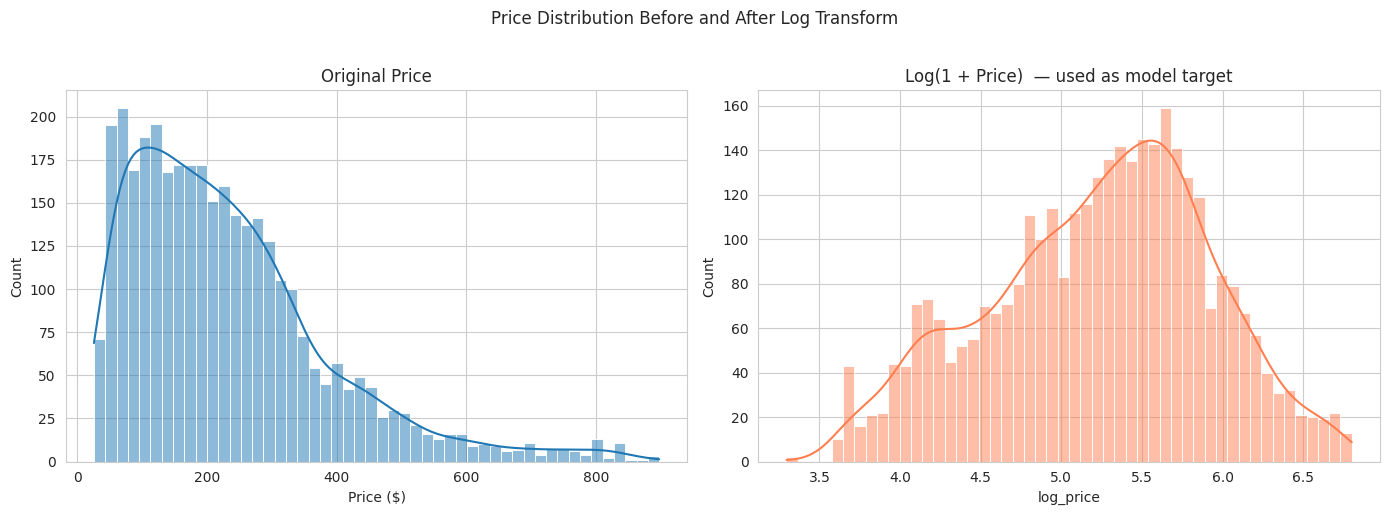

Price skewness:     1.34
log_price skewness: -0.25


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Original Price")
axes[0].set_xlabel("Price ($)")

sns.histplot(df_clean["log_price"], bins=50, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Log(1 + Price)  — used as model target")
axes[1].set_xlabel("log_price")

plt.suptitle("Price Distribution Before and After Log Transform", y=1.02)
plt.tight_layout()
plt.show()

# Skewness check
print(f"Price skewness:     {df_clean['price'].skew():.2f}")
print(f"log_price skewness: {df_clean['log_price'].skew():.2f}")


### 3.2 Numeric features vs log_price

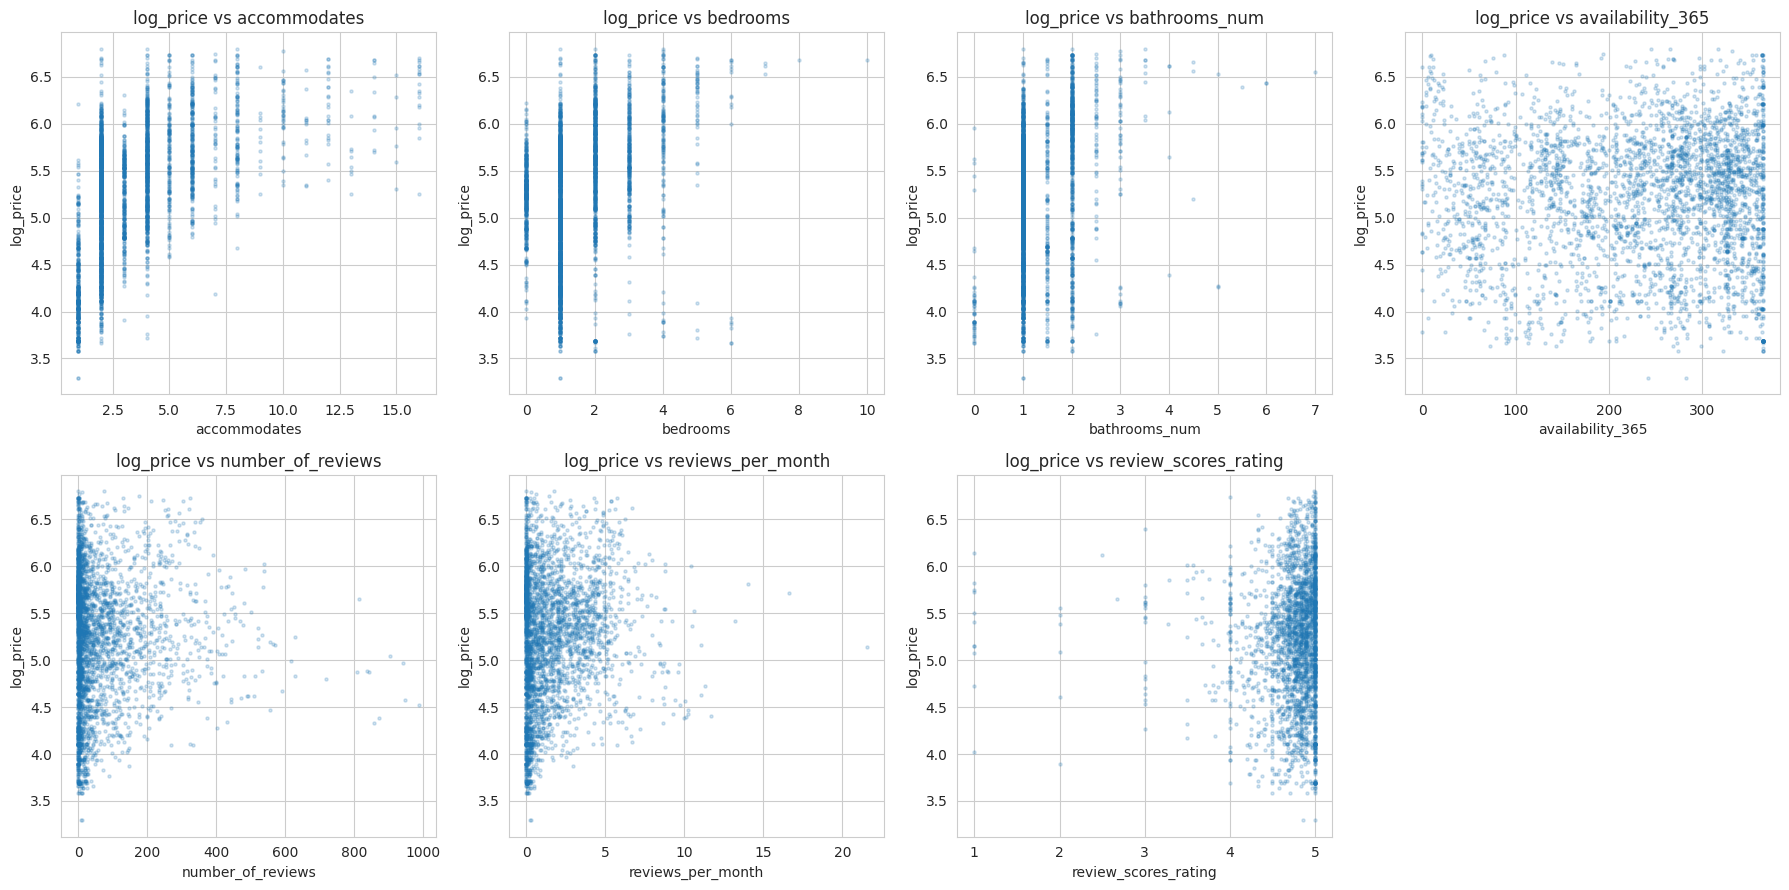

In [ ]:
numeric_features = [
    "accommodates", "bedrooms", "bathrooms_num",
    "availability_365", "number_of_reviews",
    "reviews_per_month", "review_scores_rating",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    axes[i].scatter(df_clean[feat], df_clean["log_price"], alpha=0.2, s=5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("log_price")
    axes[i].set_title(f"log_price vs {feat}")

# Hide unused subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


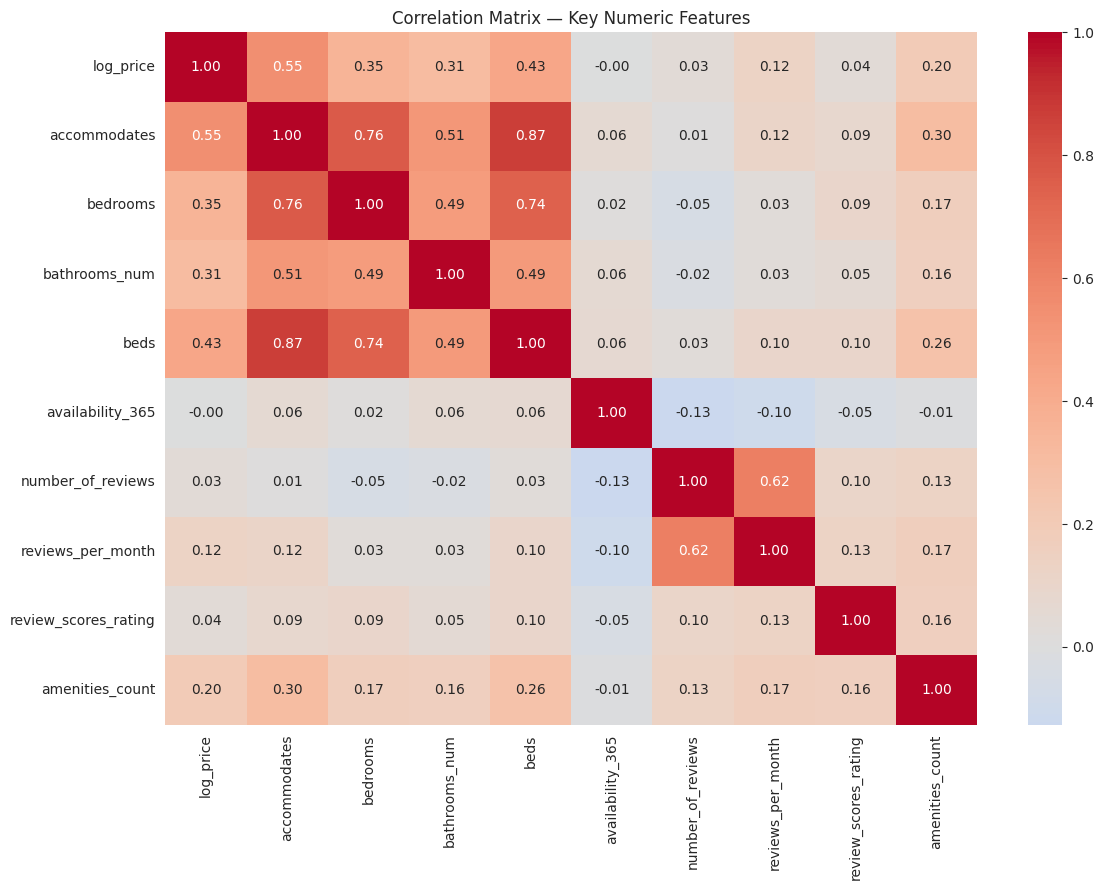

In [ ]:
# Correlation matrix for key numeric features
corr_cols = [
    "log_price", "accommodates", "bedrooms", "bathrooms_num", "beds",
    "availability_365", "number_of_reviews",
    "reviews_per_month", "review_scores_rating", "amenities_count",
]
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Key Numeric Features")
plt.tight_layout()
plt.show()
# accommodates is the strongest numeric predictor (r ≈ 0.51),
# followed by bedrooms and bathrooms_num.
# capacity features are highly inter-correlated → potential multicollinearity.


### 3.3 Categorical features vs log_price

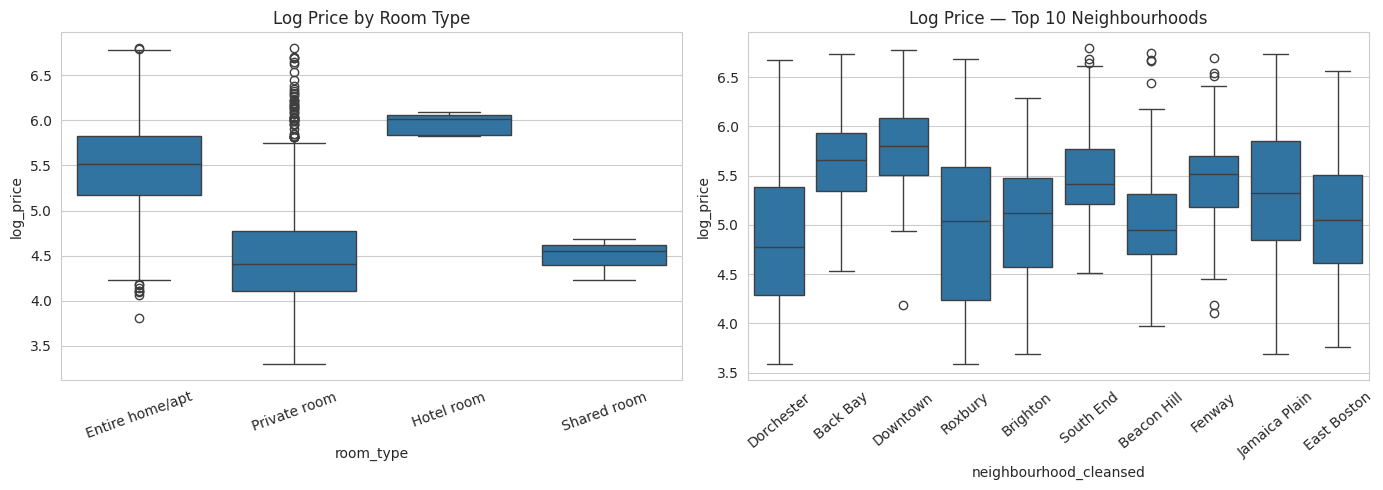

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Room type
sns.boxplot(data=df_clean, x="room_type", y="log_price", ax=axes[0])
axes[0].set_title("Log Price by Room Type")
axes[0].tick_params(axis="x", rotation=20)

# Top-10 neighbourhoods
top_neigh = df_clean["neighbourhood_cleansed"].value_counts().head(10).index
sns.boxplot(
    data=df_clean[df_clean["neighbourhood_cleansed"].isin(top_neigh)],
    x="neighbourhood_cleansed", y="log_price",
    order=top_neigh, ax=axes[1]
)
axes[1].set_title("Log Price — Top 10 Neighbourhoods")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()


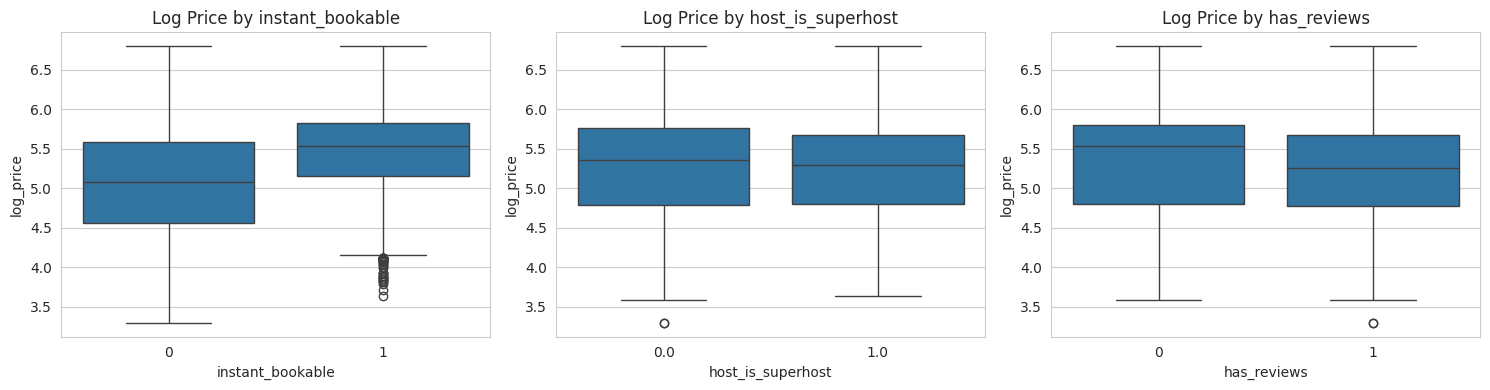

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, ["instant_bookable", "host_is_superhost", "has_reviews"]):
    sns.boxplot(data=df_clean, x=feat, y="log_price", ax=ax)
    ax.set_title(f"Log Price by {feat}")

plt.tight_layout()
plt.show()


### 3.4 Geographic distribution

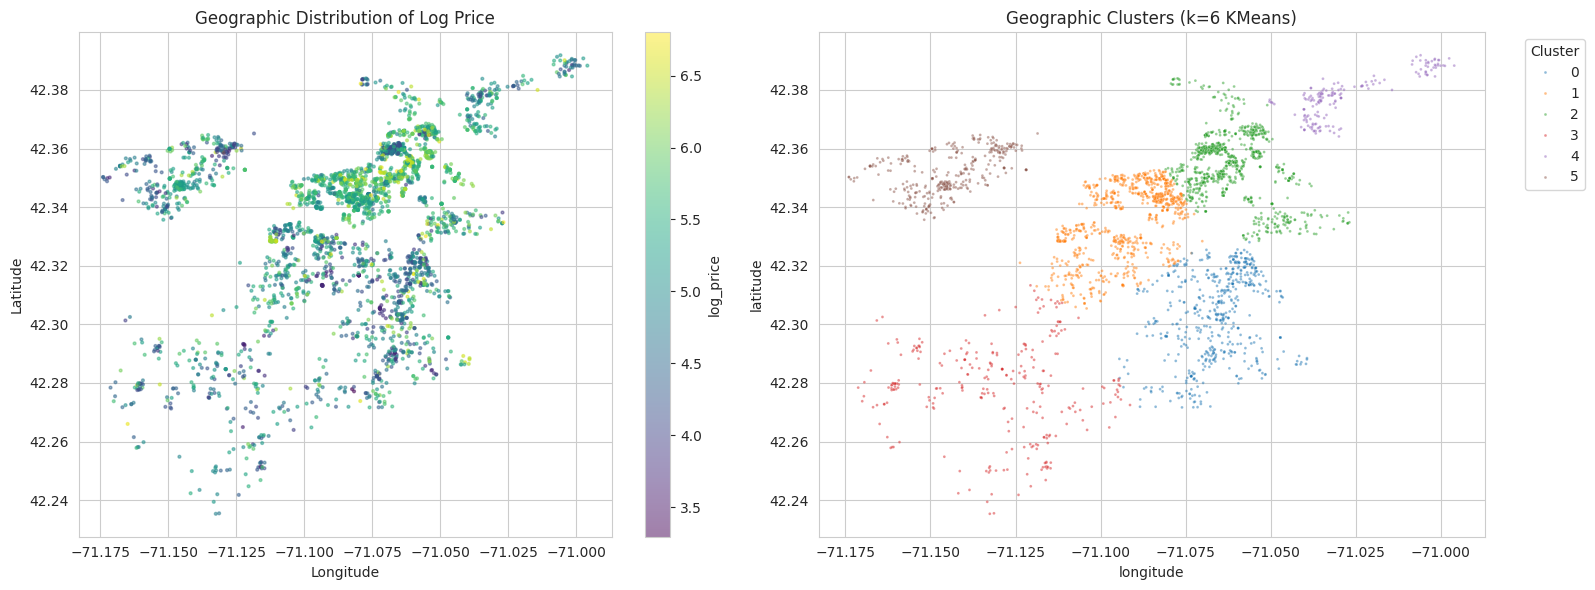

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price heat-map
sc = axes[0].scatter(
    df_clean["longitude"], df_clean["latitude"],
    c=df_clean["log_price"], cmap="viridis", alpha=0.5, s=4
)
plt.colorbar(sc, ax=axes[0], label="log_price")
axes[0].set_title("Geographic Distribution of Log Price")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

# KMeans clusters
sns.scatterplot(
    data=df_clean, x="longitude", y="latitude",
    hue="geo_cluster", palette="tab10", alpha=0.5, s=4, ax=axes[1]
)
axes[1].set_title("Geographic Clusters (k=6 KMeans)")
axes[1].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


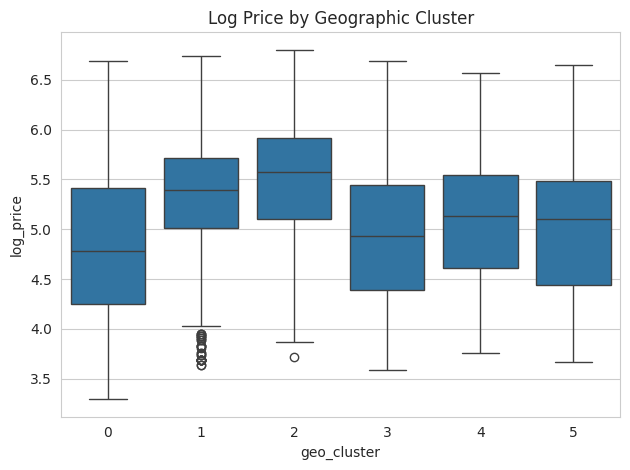

In [ ]:
# Price variation across geographic clusters
sns.boxplot(data=df_clean, x="geo_cluster", y="log_price")
plt.title("Log Price by Geographic Cluster")
plt.tight_layout()
plt.show()
# Clusters closer to downtown (Back Bay / Beacon Hill) tend to command higher prices.


---
## 4. Modeling

### 4.1 Feature selection

All four models use exactly the same feature set so results are directly comparable.

In [ ]:
# Numeric features
base_numeric_features = [
    # Physical scale
    "accommodates", "bedrooms", "beds", "bathrooms_num",
    # Amenities
    "amenities_count", "has_wifi", "has_parking",
    "has_kitchen", "has_ac", "has_workspace", "has_self_checkin",
    # Host
    "host_is_superhost", "calculated_host_listings_count",
    "instant_bookable", "host_tenure_days",
    # Reviews
    "number_of_reviews", "reviews_per_month",
    "has_reviews", "review_scores_rating", "reputation_score",
    # Availability & stay rules
    "availability_365", "minimum_nights", "maximum_nights",
    # Geography
    "geo_cluster",
]

# Categorical features (one-hot encoded by the pipeline)
categorical_features = ["room_type", "neighbourhood_cleansed"]

all_features = base_numeric_features + categorical_features

# Subset and define target
X = df_clean[all_features].copy()
y = df_clean["log_price"]   # log-transformed price

print(f"Total features: {len(all_features)}  "
      f"(numeric: {len(base_numeric_features)}, categorical: {len(categorical_features)})")
print("X shape:", X.shape)
print("y shape:", y.shape)


Total features: 26  (numeric: 24, categorical: 2)
X shape: (3415, 26)
y shape: (3415,)


### 4.2 Train / test split

Split *before* fitting any imputers or encoders to avoid data leakage.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "  Test:", X_test.shape)


Train: (2732, 26)   Test: (683, 26)


### 4.3 Preprocessing pipeline

In [ ]:
# Numeric: median imputation → standard scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical: mode imputation → one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Combine
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, base_numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


### 4.4 Model training

All four models share the same preprocessor so the only variable is the estimator.

In [ ]:
# Baseline: median-price dummy
model_dy = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DummyRegressor(strategy="median")),
])

# Linear Regression
model_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])

# Random Forest
model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42)),
])

# XGBoost
model_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(n_estimators=100, learning_rate=0.1,
                                  random_state=42)),
])

# Train
for name, model in [
    ("Dummy", model_dy),
    ("Linear Reg.", model_lr),
    ("Random Forest", model_rf),
    ("XGBoost", model_xgb),
]:
    print(f"Training {name}…", end=" ")
    model.fit(X_train, y_train)
    print("done.")


Training Dummy… done.
Training Linear Reg.… done.
Training Random Forest… done.
Training XGBoost… done.


### 4.5 Evaluation

Metrics are computed on the held-out test set. Because the target is log(1+price), MAE is reported after exponentiating back to dollars.

In [ ]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Metrics on log scale
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
    r2       = r2_score(y_test, y_pred)

    # Convert back to dollar scale for MAE
    mae_dollar = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

    print(f"── {name} ──")
    print(f"  R²:         {r2:.4f}")
    print(f"  RMSE (log): {rmse_log:.4f}")
    print(f"  MAE ($):    ${mae_dollar:.2f}\n")

    return {"Model": name, "R²": r2, "RMSE_log": rmse_log, "MAE_$": mae_dollar}


print("EVALUATION RESULTS (test set)\n")
results = []
for name, model in [
    ("Dummy Regressor", model_dy),
    ("Linear Regression", model_lr),
    ("Random Forest",     model_rf),
    ("XGBoost",           model_xgb),
]:
    results.append(evaluate_model(name, model, X_test, y_test))

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.sort_values("R²", ascending=False))


EVALUATION RESULTS (test set)

── Dummy Regressor ──
  R²:         -0.0335
  RMSE (log): 0.7118
  MAE ($):    $115.43

── Linear Regression ──
  R²:         0.7123
  RMSE (log): 0.3756
  MAE ($):    $60.68

── Random Forest ──
  R²:         0.8202
  RMSE (log): 0.2969
  MAE ($):    $46.52

── XGBoost ──
  R²:         0.8277
  RMSE (log): 0.2906
  MAE ($):    $45.78

                         R²  RMSE_log       MAE_$
Model                                            
XGBoost            0.827749  0.290604   45.778023
Random Forest      0.820211  0.296895   46.518983
Linear Regression  0.712301  0.375570   60.683415
Dummy Regressor   -0.033498  0.711830  115.426061


### 4.6 Feature importance (Random Forest)

/tmp/ipykernel_3968/2867083214.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="magma")


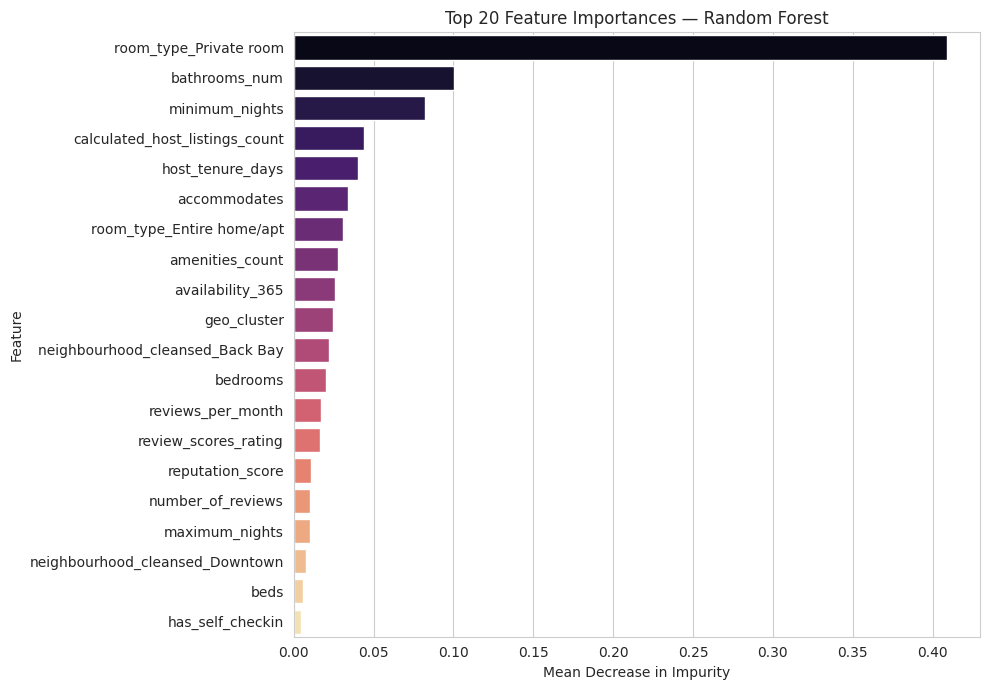

In [ ]:
# Extract feature names after OHE
ohe_feature_names = (
    model_rf.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = base_numeric_features + ohe_feature_names

importances = model_rf.named_steps["regressor"].feature_importances_

feat_imp = (
    pd.DataFrame({"Feature": all_feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 7))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="magma")
plt.title("Top 20 Feature Importances — Random Forest")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()
